# Final Integration – Meme Caption Overlay on Cartoonized Images

This notebook integrates the full pipeline:

- Uses **U-GAT-IT 100K cartoonized images** (from `1b_image_processing.ipynb`)
- Generates **mood-based captions** using a fine-tuned GPT-2 model (from `2b_caption_generation.ipynb`)
- Renders text over images using PIL (from `3a_meme_text_rendering.ipynb`)

The goal is to produce modular, mood-aware cartoon memes by combining vision and language models.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from PIL import Image
from IPython.display import display
import torch
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Project structure
PROJECT_ROOT = "/content/drive/MyDrive/cartoonify"

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "assets/memes")
MODEL_PATH = os.path.join(PROJECT_ROOT, "models/gpt2-mood-caption-v2")
IMAGE_SIZE = (256, 256)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Directories ready.")

Directories ready.


## 1. Load Caption Generator
We reuse the fine-tuned GPT-2 model from earlier (`2b_caption_generation.ipynb`).

In [4]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline
import sys

# Append helper script path
sys.path.append(os.path.join(PROJECT_ROOT, "helpers"))
import caption_helpers as helpers

# Load fine-tuned model
def load_generator(model_path):
    model = GPT2LMHeadModel.from_pretrained(model_path)
    tokenizer = GPT2Tokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token  # Fix for GPT2
    return pipeline("text-generation", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

caption_generator = load_generator(MODEL_PATH)
print("Caption generator loaded.")

Device set to use cuda:0


Caption generator loaded.


### 2. Meme Rendering with Captions
We render generated captions directly onto the cartoon images.

In [5]:
import sys
sys.path.append(os.path.join(PROJECT_ROOT, "helpers"))

from meme_helpers import create_meme_direct_pil

In [6]:
# For testing

"""
create_meme_direct_pil(
    image_path=os.path.join(CARTOON_DIR, "face01.jpg"),
    top_text="FEELING MOODY",
    bottom_text="BUT STILL CARTOON COOL",
    output_path=os.path.join(OUTPUT_DIR, "meme01.jpg"),
    size=(256, 256)
)
"""

'\ncreate_meme_direct_pil(\n    image_path=os.path.join(CARTOON_DIR, "face01.jpg"),\n    top_text="FEELING MOODY",\n    bottom_text="BUT STILL CARTOON COOL",\n    output_path=os.path.join(OUTPUT_DIR, "meme01.jpg"),\n    size=(256, 256)\n)\n'

In [9]:
#def generate_caption(mood: str = "neutral", max_length: int = 30) -> str:
#    prompt = f"mood: {mood}\ncaption:"
#    result = caption_generator(prompt, max_length=max_length, num_return_sequences=1, do_sample=True)[0]["generated_text"]
#    return result.split("caption:")[-1].strip().split("\n")[0]

def generate_caption(mood: str = "neutral") -> dict:
    return helpers.generate_meme_caption(mood, caption_generator, "fine_tuned")

In [10]:
mood = "confused"
generated_caption = generate_caption(mood)
print(f"Prompted mood: {mood}")
print(f"Generated caption: {generated_caption}")

Prompted mood: confused
Generated caption: {'mood': 'confused', 'top_text': 'YEAH I DONT KNOW', 'bottom_text': 'MAYBE IMAGINE', 'full_caption': 'YEAH I DONT KNOW MAYBE IMAGINE', 'polarity': 0.0, 'model_type': 'fine_tuned', 'raw_output': 'YEAH I DONT KNOW, MAYBE IMAGINE\nBOTTOM... SO WHY DOES...? THEN.,...OH...AND...BUT...?...SO...POWERFUL.................................................NO-WORTH.....???!??!??I ME'}


In [15]:
top_text = generated_caption["top_text"]
bottom_text = generated_caption["bottom_text"]

top_text = top_text.upper().strip()
bottom_text = bottom_text.upper().strip()

print(f"Top text: {top_text}")
print(f"Bottom text: {bottom_text}")

Top text: YEAH I DONT KNOW
Bottom text: MAYBE IMAGINE


In [19]:
# Define the paths for the training directories
train_A_path = "/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/trainA"
train_B_path = "/content/drive/MyDrive/cartoonify/UGATIT/dataset/selfie2anime/trainB"

# Create the directories if they don't exist
os.makedirs(train_A_path, exist_ok=True)
os.makedirs(train_B_path, exist_ok=True)

# Create a dummy white image
dummy_image = Image.new('RGB', (256, 256), color='white')

# Save the dummy image into both training folders
dummy_image.save(os.path.join(train_A_path, "dummy.jpg"))
dummy_image.save(os.path.join(train_B_path, "dummy.jpg"))

print("Dummy images created in trainA and trainB folders to satisfy data loader.")

Dummy images created in trainA and trainB folders to satisfy data loader.


In [21]:
# Load cartoonization model (UGAT-IT 100K)
sys.path.append(os.path.join(PROJECT_ROOT, "UGATIT"))

from UGATIT import UGATIT
from argparse import Namespace
from types import MethodType

# Set the working directory to the U-GAT-IT project root
ugatit_path = "/content/drive/MyDrive/cartoonify/UGATIT"
os.chdir(ugatit_path)

print(f"Current working directory changed to: {os.getcwd()}")

def get_config():
    return Namespace(
        dataset='selfie2anime',
        phase='test',
        light=False,
        ch=64,
        n_res=6,
        n_dis=6,
        img_size=256,
        img_ch=3,
        batch_size=1,
        iteration=100000,
        decay_flag=True,
        print_freq=100,
        save_freq=1000,
        lr=0.0001,
        weight_decay=0.0001,
        adv_weight=1,
        cycle_weight=10,
        identity_weight=10,
        cam_weight=1000,
        result_dir='results',
        checkpoint_dir=os.path.join(PROJECT_ROOT, "models/vision/checkpoints"),
        log_dir='log',
        sample_dir='sample',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        benchmark_flag=True,
        resume=None
    )

def infer_single_image(self, input_path, output_path):
    from torchvision import transforms
    img = PILImage.open(input_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((self.img_size, self.img_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    img_tensor = transform(img).unsqueeze(0).to(self.device)
    with torch.no_grad():
        output = self.genA2B(img_tensor)
        if isinstance(output, tuple):
            output = output[0]
        out = (output.squeeze(0).cpu().numpy().transpose(1, 2, 0) + 1) / 2
        out = (out * 255).clip(0, 255).astype("uint8")
        PILImage.fromarray(out).save(output_path)

def load_inference_model():
    config = get_config()
    model = UGATIT(config)
    model.build_model()
    ckpt = torch.load(os.path.join(config.checkpoint_dir, "genA2B_final.pth"), map_location=config.device)
    model.genA2B.load_state_dict(ckpt)
    model.genA2B.eval()
    model.infer_single_image = MethodType(infer_single_image, model)
    return model

inference_model = load_inference_model()

Current working directory changed to: /content/drive/.shortcut-targets-by-id/1Rx57z2rxsTNUFOigb--5PS4EtWI_fGHU/cartoonify/UGATIT
set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  1
# iteration per epoch :  100000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000


## 3. Meme Creation from Raw Human Face Images

We now apply the full pipeline to real human selfies by:
- Converting each selfie to cartoon using U-GAT-IT (100K)
- Generating a mood-aware caption using GPT-2
- Rendering the meme using our custom overlay function


--- Processing Image 1/3 ---
Original image path: /content/drive/MyDrive/cartoonify/assets/raw_humanface/0350.jpg
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_01.jpg


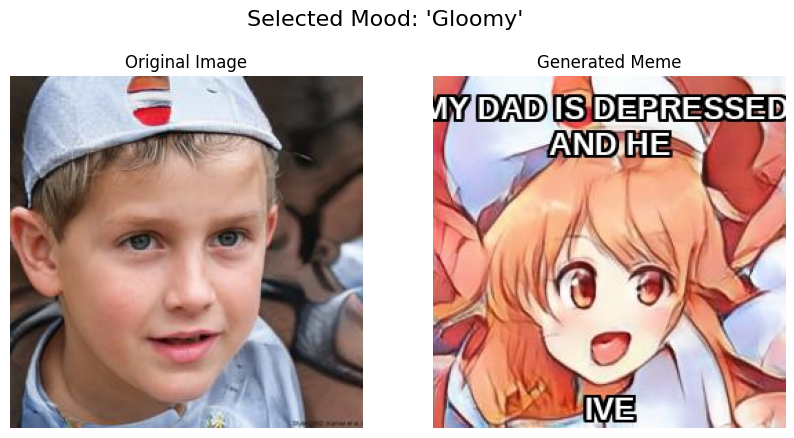

--- Processing Image 2/3 ---
Original image path: /content/drive/MyDrive/cartoonify/assets/raw_humanface/0268.jpg
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_02.jpg


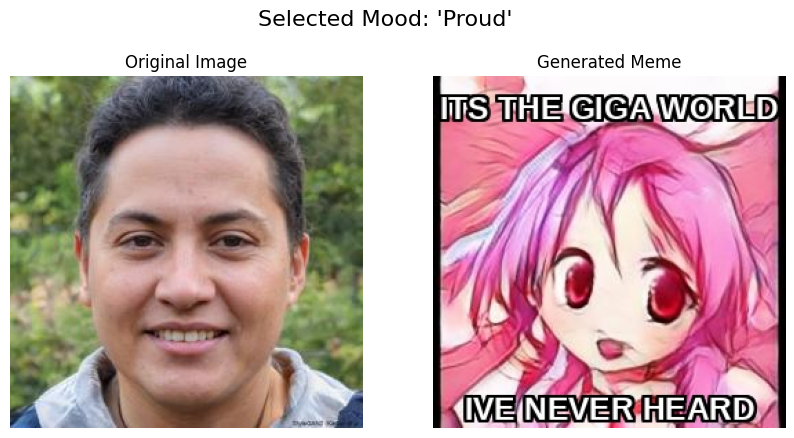

--- Processing Image 3/3 ---
Original image path: /content/drive/MyDrive/cartoonify/assets/raw_humanface/0279.jpg
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_03.jpg


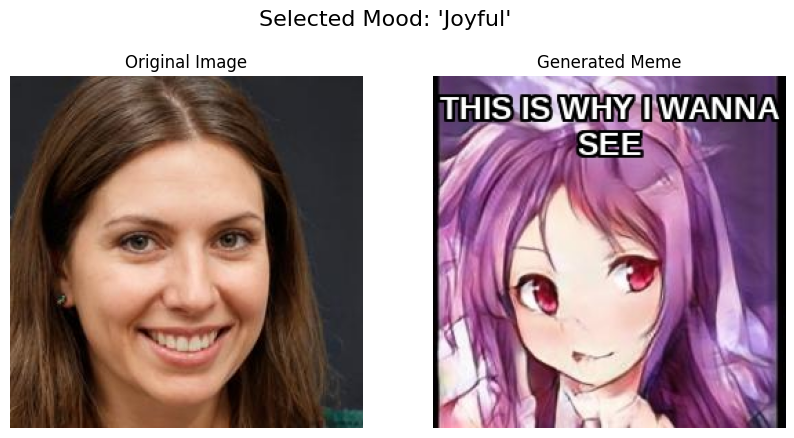


Processing complete.


In [88]:
from glob import glob
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

RAW_INPUT_DIR = os.path.join(PROJECT_ROOT, "assets/raw_humanface")
image_paths = sorted(glob(os.path.join(RAW_INPUT_DIR, "*.jpg")))
moods = ["confused", "joyful", "angry", "proud", "sarcastic", "gloomy"]

"""
for i, img_path in enumerate(image_paths[:10]):
    # Step 1: Cartoonize
    cartoon_path = os.path.join(OUTPUT_DIR, f"cartoon_face_{i+1:02}.jpg")
    inference_model.infer_single_image(img_path, cartoon_path)

    # Step 2: Caption
    mood = random.choice(moods)
    caption = generate_caption(mood)

    top_text = caption["top_text"].strip().upper()
    bottom_text = caption["bottom_text"].strip().capitalize()

    # Step 3: Render Meme
    meme_path = os.path.join(OUTPUT_DIR, f"meme_{i+1:02}.jpg")
    create_meme_direct_pil(
        image_path=cartoon_path,
        top_text=top_text,
        bottom_text=bottom_text,
        output_path=meme_path,
        size=IMAGE_SIZE
    )

    display(PILImage.open(meme_path))
"""

# Process 3 random images for a cleaner output
num_images_to_show = 3
if len(image_paths) > num_images_to_show:
    selected_paths = random.sample(image_paths, num_images_to_show)
else:
    selected_paths = image_paths


for i, img_path in enumerate(selected_paths):
    print(f"--- Processing Image {i+1}/{len(selected_paths)} ---")
    print(f"Original image path: {img_path}")

    # Step 1: Cartoonize
    cartoon_path = os.path.join(OUTPUT_DIR, f"cartoon_face_{i+1:02}.jpg")
    inference_model.infer_single_image(img_path, cartoon_path)

    # Step 2: Caption
    mood = random.choice(moods)
    caption = generate_caption(mood)
    top_text = caption["top_text"].strip().upper()
    # Using .upper() for bottom text is more standard for memes
    bottom_text = caption["bottom_text"].strip().upper()

    # Step 3: Render Meme
    meme_path = os.path.join(OUTPUT_DIR, f"meme_{i+1:02}.jpg")
    create_meme_direct_pil(
        image_path=cartoon_path,
        top_text=top_text,
        bottom_text=bottom_text,
        output_path=meme_path,
        size=IMAGE_SIZE
    )

    # Step 4: Display the original and the final meme side-by-side
    original_image = PILImage.open(img_path)
    meme_image = PILImage.open(meme_path)

    # Create a figure and a set of subplots
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    # Display Original Image
    ax[0].imshow(original_image)
    ax[0].set_title("Original Image")
    ax[0].axis('off') # Hide axes ticks

    # Display Generated Meme
    ax[1].imshow(meme_image)
    ax[1].set_title("Generated Meme")
    ax[1].axis('off') # Hide axes ticks

    # Add the mood as the main title for the plot
    fig.suptitle(f"Selected Mood: '{mood.capitalize()}'", fontsize=16)

    plt.show()

print("\nProcessing complete.")

In [91]:
import types

def load_inference_model_by_iteration(iteration_count):
    """Loads a U-GAT-IT generator model from a specific training iteration."""
    print(f"--- Loading U-GAT-IT model trained for {iteration_count:,} iterations ---")
    config = get_config()
    # Update the config to reflect the iteration count we are loading
    config.iteration = iteration_count

    model = UGATIT(config)
    model.build_model()

    # Construct the specific checkpoint file name
    checkpoint_file = f"UGATIT_selfie2anime_genA2B_{iteration_count}.pth"
    checkpoint_path = os.path.join(config.checkpoint_dir, checkpoint_file)

    if not os.path.exists(checkpoint_path):
        print(f"ERROR: Checkpoint file not found at {checkpoint_path}")
        return None

    # Load the state dictionary from the specific checkpoint
    ckpt = torch.load(checkpoint_path, map_location=config.device)
    model.genA2B.load_state_dict(ckpt)
    model.genA2B.eval()

    # Dynamically attach the inference method to the model instance
    model.infer_single_image = types.MethodType(infer_single_image, model)

    print(f"Successfully loaded model from iteration {iteration_count:,}.\n")
    return model

# Load both the 15K and 50K iteration models
inference_model_15k = load_inference_model_by_iteration(15000)
inference_model_50k = load_inference_model_by_iteration(50000)

--- Loading U-GAT-IT model trained for 15,000 iterations ---
set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  1
# iteration per epoch :  15000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
Successfully loaded model from iteration 15,000.

--- Loading U-GAT-IT model trained for 50,000 iterations ---
set benchmark !

##### Information #####
# light :  False
# dataset :  selfie2anime
# batch_size :  1
# iteration per epoch :  50000

##### Generator #####
# residual blocks :  6

##### Discriminator #####
# discriminator layer :  6

##### Weight #####
# adv_weight :  1
# cycle_weight :  10
# identity_weight :  10
# cam_weight :  1000
Successfully loaded model from iteration 50,000.





--- Starting Comparison Test for 15K and 50K Models ---

--- Testing with model: 15k_iterations ---
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_15k_iterations_01.jpg


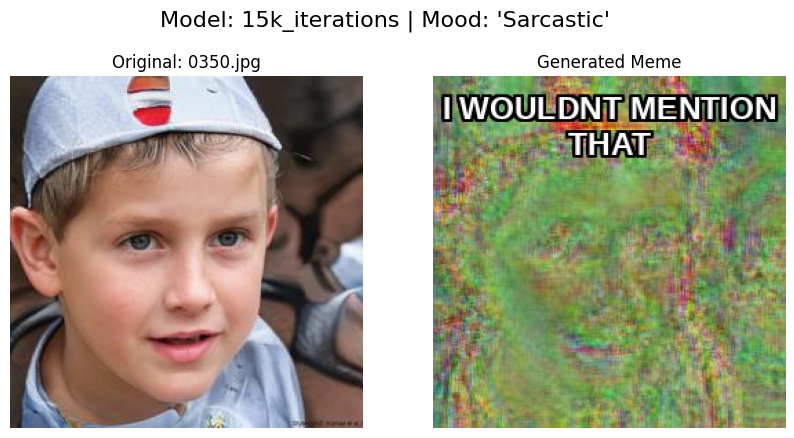

Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_15k_iterations_02.jpg


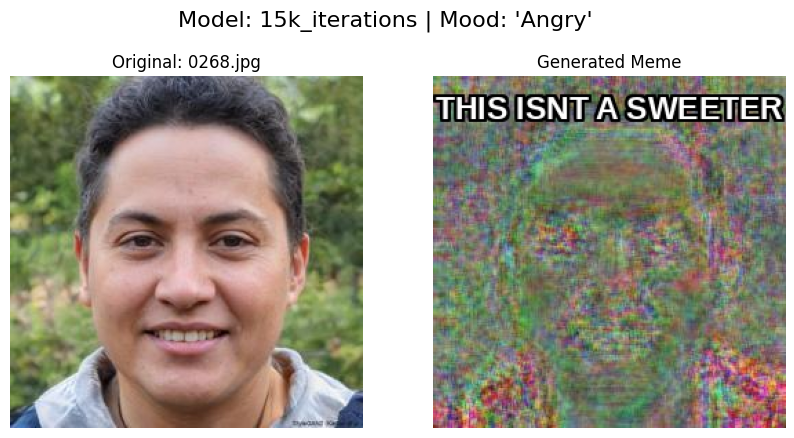

Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_15k_iterations_03.jpg


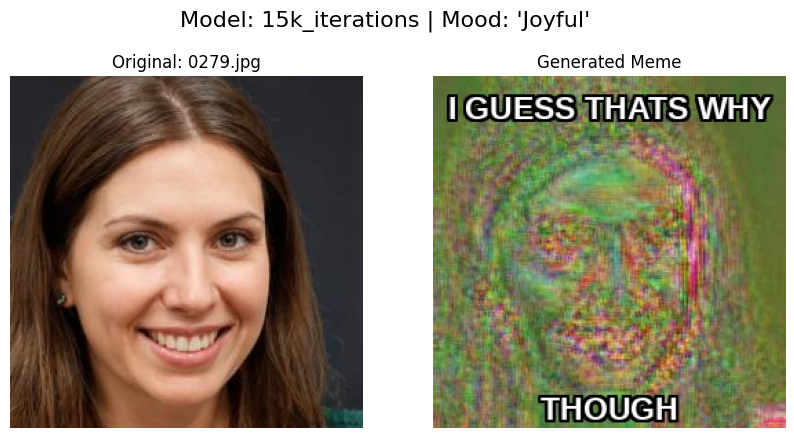


--- Testing with model: 50k_iterations ---
Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_50k_iterations_01.jpg


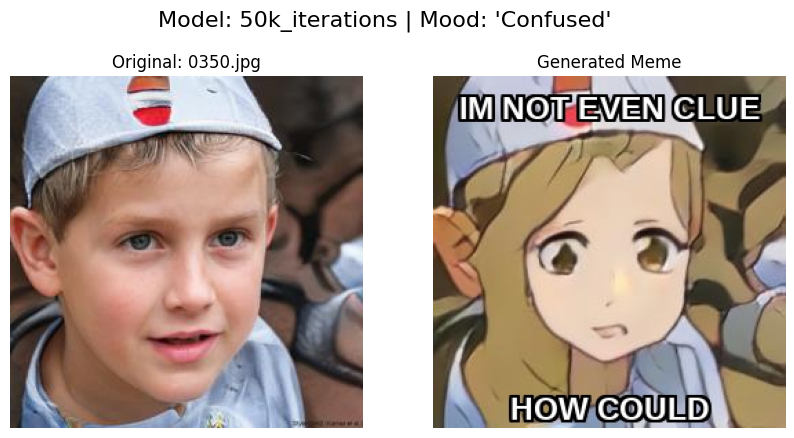

Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_50k_iterations_02.jpg


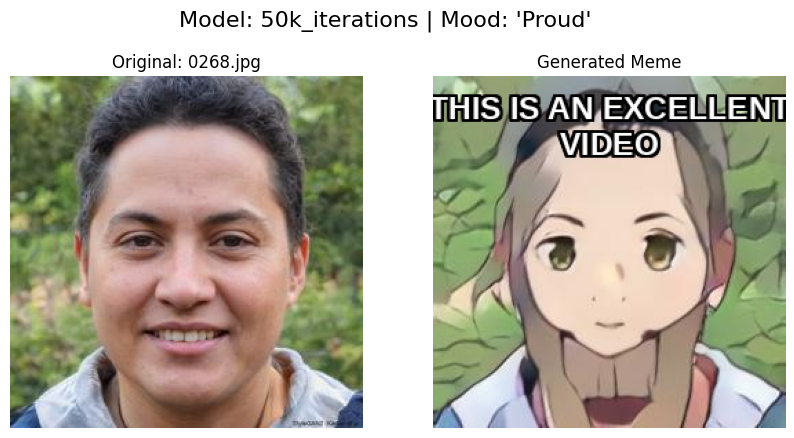

Using font: /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf
Meme created and saved: /content/drive/MyDrive/cartoonify/assets/memes/meme_50k_iterations_03.jpg


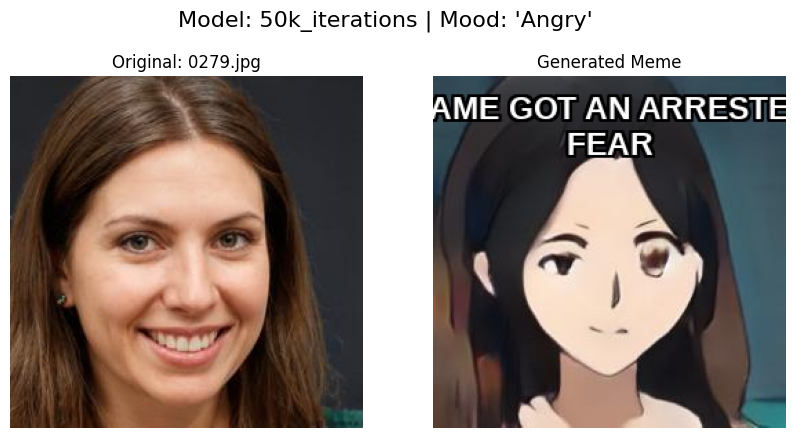

In [93]:
# List of specific images you want to re-test
image_paths_to_test = [
    "/content/drive/MyDrive/cartoonify/assets/raw_humanface/0350.jpg",
    "/content/drive/MyDrive/cartoonify/assets/raw_humanface/0268.jpg",
    "/content/drive/MyDrive/cartoonify/assets/raw_humanface/0279.jpg"
]

# Dictionary of the models you want to test
models_to_test = {
    "15k_iterations": inference_model_15k,
    "50k_iterations": inference_model_50k
}

print("\n\n--- Starting Comparison Test for 15K and 50K Models ---")

for model_name, model in models_to_test.items():
    if model is None:
        print(f"Skipping {model_name} because the model could not be loaded.")
        continue

    print(f"\n--- Testing with model: {model_name} ---")

    for i, img_path in enumerate(image_paths_to_test):
        # Use a random mood for each image
        mood = random.choice(moods)

        # Step 1: Cartoonize the image using the selected model
        cartoon_path = os.path.join(OUTPUT_DIR, f"cartoon_{model_name}_{i+1:02}.jpg")
        model.infer_single_image(img_path, cartoon_path)

        # Step 2: Generate a caption for the selected mood
        caption = generate_caption(mood)
        top_text = caption["top_text"].strip().upper()
        bottom_text = caption["bottom_text"].strip().upper()

        # Step 3: Render the final meme
        meme_path = os.path.join(OUTPUT_DIR, f"meme_{model_name}_{i+1:02}.jpg")
        create_meme_direct_pil(
            image_path=cartoon_path,
            top_text=top_text,
            bottom_text=bottom_text,
            output_path=meme_path,
            size=IMAGE_SIZE
        )

        # Step 4: Display the results side-by-side
        original_image = PILImage.open(img_path)
        meme_image = PILImage.open(meme_path)

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"Model: {model_name} | Mood: '{mood.capitalize()}'", fontsize=16)

        ax[0].imshow(original_image)
        ax[0].set_title(f"Original: {os.path.basename(img_path)}")
        ax[0].axis('off')

        ax[1].imshow(meme_image)
        ax[1].set_title("Generated Meme")
        ax[1].axis('off')

        plt.show()

### Conclusion

This notebook completes our end-to-end creative generation pipeline by integrating:
* A **cartoonized image generator** (U-GAT-IT at 100K iterations)
* A **mood-conditioned caption generator** (fine-tuned GPT-2)
* A **custom meme renderer** using PIL

The final 100K iteration U-GAT-IT model was selected after a qualitative visual assessment of outputs from different training steps. By combining these independently trained vision and language models, we successfully created a modular pipeline for generating expressive, emotionally-aware memes.

**Future improvements could include:**
* Quantitative analysis of image quality using **LPIPS or FID scores**.
* Caption reranking, filtering, and the addition of mood-based emojis.
* Using **CLIP** to better score the semantic alignment between the image and text.
* Conducting **human evaluation** via user preference tests for a holistic quality assessment.